## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [4]:
df.shape

(50, 15)

In [6]:
df["year"].value_counts()

year
2019    10
2020    10
2021    10
2022    10
2023    10
Name: count, dtype: int64

In [8]:
df["brand"].value_counts()

brand
chefman        5
cosori         5
cuisinart      5
dash           5
gowise usa     5
instant_pot    5
ninja          5
nuwave         5
oster          5
ultrean        5
Name: count, dtype: int64

In [15]:
df["year"].groupby(df["brand"]).value_counts()

brand        year
chefman      2019    1
             2020    1
             2021    1
             2022    1
             2023    1
cosori       2019    1
             2020    1
             2021    1
             2022    1
             2023    1
cuisinart    2019    1
             2020    1
             2021    1
             2022    1
             2023    1
dash         2019    1
             2020    1
             2021    1
             2022    1
             2023    1
gowise usa   2019    1
             2020    1
             2021    1
             2022    1
             2023    1
instant_pot  2019    1
             2020    1
             2021    1
             2022    1
             2023    1
ninja        2019    1
             2020    1
             2021    1
             2022    1
             2023    1
nuwave       2019    1
             2020    1
             2021    1
             2022    1
             2023    1
oster        2019    1
             2020    1
             202

In [16]:
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


<Axes: xlabel='brand', ylabel='avg_price'>

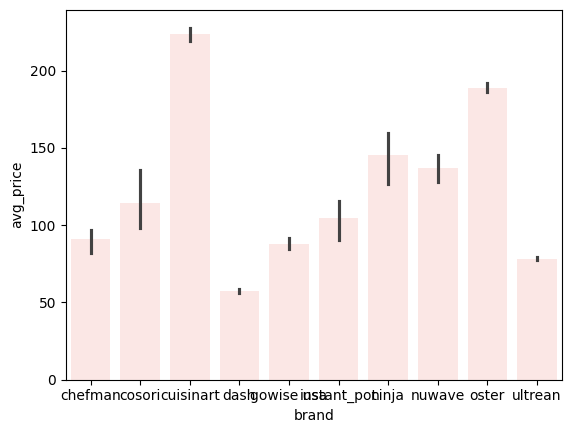

In [19]:
sns.barplot(data = df, x = "brand", y = "avg_price", color = "mistyrose")

<Axes: xlabel='brand', ylabel='avg_rating'>

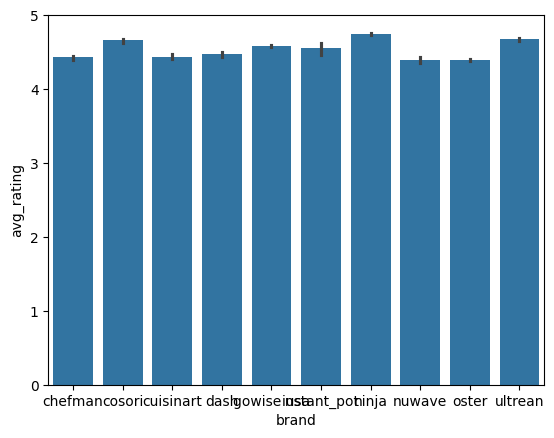

In [20]:
sns.barplot(data = df, x = "brand", y = "avg_rating")

<Axes: xlabel='brand', ylabel='compact_share'>

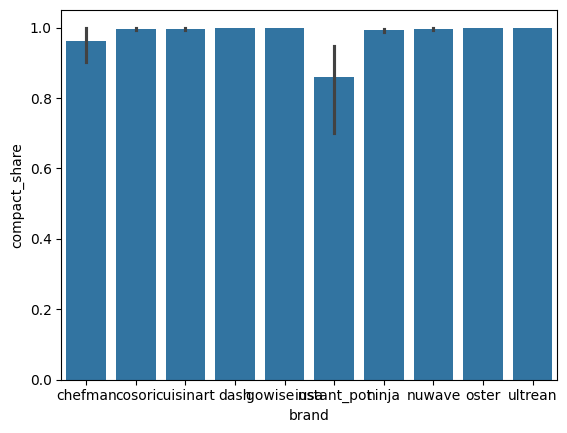

In [22]:
sns.barplot(data = df, x = "brand", y = "compact_share")

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$? **The estimated price coefficient is -0.03766765298429372.**
2. Is it negative? Why is that important? **It is negative. That is important because the interpretation is that a 1 unit increase in price leads to about 3.7% decrease in brand share.**
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [40]:
from sklearn.linear_model import LinearRegression

brand_dummies = pd.get_dummies(df["brand"], drop_first = True)
year_dummies = pd.get_dummies(df["year"], drop_first = True)


X = pd.concat([df[["avg_price", "avg_rating", "compact_share", "dual_basket_share",
       "oven_style_share", "rotisserie_share", "window_share", "market_purchases"]], brand_dummies, year_dummies], axis = 1)
y = df["log_brand_share"]
X.columns = X.columns.astype(str)

model = LinearRegression()
model.fit(X, y)
b_price = model.coef_[X.columns.get_loc("avg_price")]
b_price


np.float64(-0.03766765298429372)